In [ ]:
import sys  # Gives access to the Python executable that is running this notebook.
import subprocess  # Lets Python run command-line tools such as pip.

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)  # Installs the Kaggle API package quietly.
print("Kaggle API package is installed and ready.")  # Confirms that the install step finished.


Kaggle API package is installed and ready.


**What this block does:**  
It installs the Kaggle API package so Colab can download the Titanic competition files directly from Kaggle.


In [ ]:
import os  # Lets us work with operating-system settings and file permissions.
from pathlib import Path  # Makes file paths easier to build and read.

try:  # Starts a safe check for whether this notebook is running inside Google Colab.
    from google.colab import files  # Imports Colab's file upload helper when available.
    IN_COLAB = True  # Records that we are inside Colab.
except ImportError:  # Runs if the notebook is not inside Colab.
    IN_COLAB = False  # Records that we are not inside Colab.

kaggle_dir = Path.home() / ".kaggle"  # Chooses the standard folder where Kaggle credentials should live.
kaggle_dir.mkdir(parents=True, exist_ok=True)  # Creates the Kaggle folder if it does not already exist.
kaggle_json_path = kaggle_dir / "kaggle.json"  # Builds the full path to the Kaggle API key file.
os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir)  # Tells the Kaggle package exactly where to look for the key file.

if not kaggle_json_path.exists():  # Checks whether the Kaggle key file is already present.
    if not IN_COLAB:  # Stops with a helpful message if this is not being run in Colab.
        raise RuntimeError("This notebook is designed for Google Colab. If you are running elsewhere, place kaggle.json in ~/.kaggle first.")  # Explains how to continue outside Colab.
    print("Upload your kaggle.json file now.")  # Prompts the user to upload their Kaggle API key.
    uploaded_files = files.upload()  # Opens the Colab upload dialog and stores the uploaded file data.
    if "kaggle.json" not in uploaded_files:  # Verifies that the required Kaggle key file was uploaded.
        raise FileNotFoundError("You must upload a file named kaggle.json to continue.")  # Stops if the wrong file was uploaded.
    with open(kaggle_json_path, "wb") as kaggle_file:  # Opens the destination file in binary write mode.
        kaggle_file.write(uploaded_files["kaggle.json"])  # Saves the uploaded Kaggle key into the correct folder.
else:  # Runs when the Kaggle key file already exists.
    print("kaggle.json is already available, so no upload is needed.")  # Lets the user know the setup is already done.

os.chmod(kaggle_json_path, 0o600)  # Locks down the file permissions so Kaggle accepts the key file.
print(f"Kaggle credentials are ready at: {kaggle_json_path}")  # Shows the final location of the Kaggle key.


Upload your kaggle.json file now.


Saving kaggle.json to kaggle.json
Kaggle credentials are ready at: /root/.kaggle/kaggle.json


**What this block does:**  
It uploads your `kaggle.json` file into the correct Colab folder and sets the file permissions Kaggle expects.


In [ ]:
import zipfile  # Lets us extract compressed ZIP files after downloading them.

data_dir = Path("/content/titanic_data")  # Chooses a simple folder inside Colab for the competition files.
data_dir.mkdir(parents=True, exist_ok=True)  # Creates the data folder if it does not already exist.
zip_path = data_dir / "titanic.zip"  # Sets the path where the downloaded Kaggle ZIP file will be stored.

download_command = ["kaggle", "competitions", "download", "-c", "titanic", "-p", str(data_dir)]  # Builds the Kaggle CLI command that downloads the Titanic competition files.

if not (data_dir / "train.csv").exists():  # Checks whether the main training file has already been extracted.
    if not zip_path.exists():  # Checks whether the ZIP file has already been downloaded.
        result = subprocess.run(download_command, text=True, capture_output=True)  # Runs the Kaggle download command and captures its output.
        print(result.stdout)  # Prints the normal Kaggle output so you can see what happened.
        if result.returncode != 0:  # Checks whether the Kaggle command failed.
            print(result.stderr)  # Prints the Kaggle error message so the problem is easy to diagnose.
            raise RuntimeError("Kaggle download failed. Read the error message printed above.")  # Stops the notebook with a clear explanation if the download failed.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:  # Opens the downloaded ZIP file for reading.
        zip_ref.extractall(data_dir)  # Extracts all competition files into the data folder.
else:  # Runs when the CSV files are already present from an earlier run.
    print("Competition files are already available, so the download step is skipped.")  # Explains why nothing new was downloaded.

expected_files = ["train.csv", "test.csv", "gender_submission.csv"]  # Lists the files we expect Kaggle to provide.
for file_name in expected_files:  # Loops through each expected file name.
    file_path = data_dir / file_name  # Builds the full path to the expected file.
    print(f"{file_name}: {'found' if file_path.exists() else 'missing'}")  # Reports whether each file is present.

print(f"Data folder: {data_dir}")  # Shows where the Titanic files are stored in Colab.




train.csv: found
test.csv: found
gender_submission.csv: found
Data folder: /content/titanic_data


**What this block does:**  
It downloads the Titanic competition files with the Kaggle CLI, prints any real error message if the download fails, extracts the ZIP file, and checks that the three expected files are present.


In [ ]:
import numpy as np  # Adds numerical tools used for calculations and feature engineering.
import pandas as pd  # Adds table tools used to load and manipulate CSV data.
import matplotlib.pyplot as plt  # Adds plotting tools for simple charts.
from IPython.display import display  # Lets the notebook show DataFrames more cleanly.

train_df = pd.read_csv(data_dir / "train.csv")  # Loads the labeled training data from Kaggle into a DataFrame.
test_df = pd.read_csv(data_dir / "test.csv")  # Loads the unlabeled test data from Kaggle into a DataFrame.
gender_submission_df = pd.read_csv(data_dir / "gender_submission.csv")  # Loads Kaggle's example submission file.

print(f"Training shape: {train_df.shape}")  # Prints the row and column count for the training data.
print(f"Test shape: {test_df.shape}")  # Prints the row and column count for the test data.
print(f"Example submission shape: {gender_submission_df.shape}")  # Prints the row and column count for the example submission file.

display(train_df.head())  # Displays the first few training rows so we can inspect the columns.


Training shape: (891, 12)
Test shape: (418, 11)
Example submission shape: (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**What this block does:**  
It imports the main libraries, loads the Titanic CSV files, prints their shapes, and shows the first few rows of the training set.


In [ ]:
missing_summary = train_df.isna().sum().to_frame("missing_count")  # Counts the number of missing values in each training column.
missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(train_df) * 100).round(2)  # Converts the missing-value counts into percentages.

print("Training data information:")  # Prints a label before the dataset structure output.
train_df.info()  # Shows data types, non-null counts, and memory usage for the training set.

print("\nMissing-value summary:")  # Prints a label before the missing-value table.
display(missing_summary.sort_values("missing_count", ascending=False))  # Displays the missing-value summary from highest missing count to lowest.

print("\nTarget distribution:")  # Prints a label before the survival counts.
display(train_df["Survived"].value_counts().rename_axis("Survived").to_frame("count"))  # Displays the number of passengers in each survival class.


Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing-value summary:


,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00



Target distribution:


,count
Survived,
0,549
1,342


**What this block does:**  
It checks the data types, shows how much information is missing, and counts how many passengers survived versus did not survive.


Women's survival rate: 0.742
Men's survival rate: 0.189

Survival rate by passenger class:


,survival_rate
Pclass,
1,0.629630
2,0.472826
3,0.242363



Survival rate by embarkation port:


,survival_rate
Embarked,
C,0.553571
Q,0.389610
S,0.336957


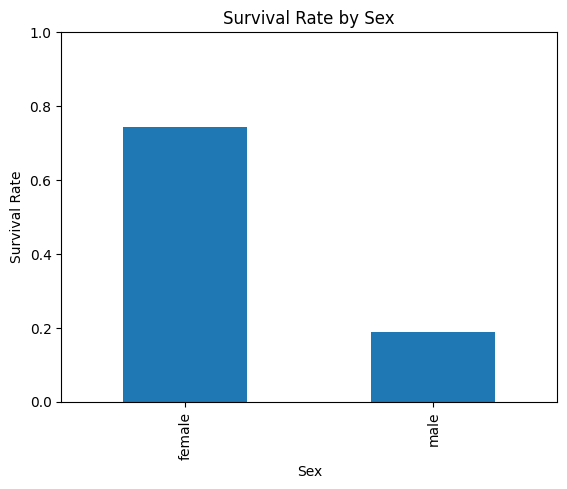

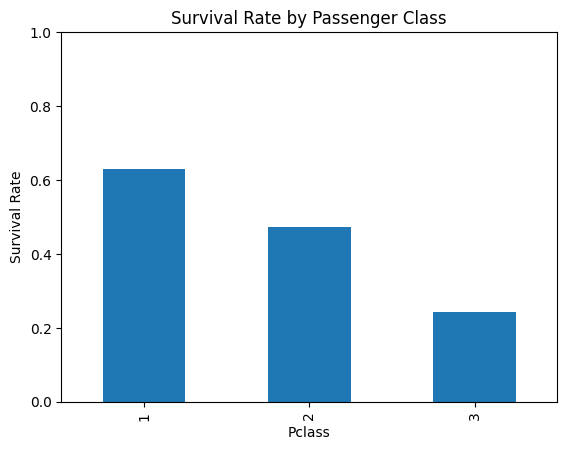

In [ ]:
women_survival_rate = train_df.loc[train_df["Sex"] == "female", "Survived"].mean()  # Computes the average survival rate for women.
men_survival_rate = train_df.loc[train_df["Sex"] == "male", "Survived"].mean()  # Computes the average survival rate for men.
survival_by_class = train_df.groupby("Pclass")["Survived"].mean().sort_index()  # Computes average survival rate for each passenger class.
survival_by_embarked = train_df.groupby("Embarked")["Survived"].mean().sort_index()  # Computes average survival rate for each embarkation port.

print(f"Women's survival rate: {women_survival_rate:.3f}")  # Prints the female survival rate.
print(f"Men's survival rate: {men_survival_rate:.3f}")  # Prints the male survival rate.

print("\nSurvival rate by passenger class:")  # Prints a label before the passenger-class table.
display(survival_by_class.rename("survival_rate").to_frame())  # Displays class-level survival rates as a table.

print("\nSurvival rate by embarkation port:")  # Prints a label before the embarkation table.
display(survival_by_embarked.rename("survival_rate").to_frame())  # Displays embarkation-level survival rates as a table.

sex_survival_table = train_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)  # Builds a small table for the bar chart.
sex_survival_table.plot(kind="bar", title="Survival Rate by Sex")  # Draws a bar chart showing survival rate by sex.
plt.ylabel("Survival Rate")  # Labels the y-axis of the bar chart.
plt.ylim(0, 1)  # Sets the chart scale from 0 to 1 because survival rate is a proportion.
plt.show()  # Displays the first chart.

survival_by_class.plot(kind="bar", title="Survival Rate by Passenger Class")  # Draws a bar chart showing survival rate by passenger class.
plt.ylabel("Survival Rate")  # Labels the y-axis of the second chart.
plt.ylim(0, 1)  # Sets the chart scale from 0 to 1 for the second chart too.
plt.show()  # Displays the second chart.


**What this block does:**  
It measures a few important survival patterns and visualizes two of the clearest ones: sex and passenger class.


In [ ]:
def add_engineered_features(df):  # Defines a reusable function that creates better features from the raw Titanic columns.
    df = df.copy()  # Makes a copy so the original DataFrame does not get changed accidentally.
    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).fillna("Unknown")  # Extracts titles such as Mr, Mrs, and Miss from each passenger name.
    title_replacements = {  # Starts a mapping that combines rare or similar titles into cleaner groups.
        "Mlle": "Miss",  # Maps Mlle to Miss.
        "Ms": "Miss",  # Maps Ms to Miss.
        "Mme": "Mrs",  # Maps Mme to Mrs.
        "Lady": "Rare",  # Maps Lady to a rare-title group.
        "Countess": "Rare",  # Maps Countess to a rare-title group.
        "Capt": "Rare",  # Maps Capt to a rare-title group.
        "Col": "Rare",  # Maps Col to a rare-title group.
        "Don": "Rare",  # Maps Don to a rare-title group.
        "Dr": "Rare",  # Maps Dr to a rare-title group.
        "Major": "Rare",  # Maps Major to a rare-title group.
        "Rev": "Rare",  # Maps Rev to a rare-title group.
        "Sir": "Rare",  # Maps Sir to a rare-title group.
        "Jonkheer": "Rare",  # Maps Jonkheer to a rare-title group.
        "Dona": "Rare",  # Maps Dona to a rare-title group.
    }  # Ends the title-replacement dictionary.
    df["Title"] = df["Title"].replace(title_replacements)  # Applies the title-cleaning rules to the extracted title column.
    df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Miss", "Mrs", "Master"]), "Rare")  # Keeps common titles and groups all other titles into Rare.
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1  # Counts how many family members, including the passenger, are traveling together.
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)  # Creates a 1 or 0 flag for whether the passenger is alone.
    df["CabinKnown"] = df["Cabin"].notna().astype(int)  # Creates a 1 or 0 flag for whether cabin information is present.
    df["Deck"] = df["Cabin"].fillna("Missing").astype(str).str[0]  # Extracts the first cabin letter as a rough deck indicator and uses Missing when cabin is unknown.
    df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")  # Counts how many passengers share the same ticket number.
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]  # Estimates how much fare corresponds to each person in the family group.
    df["FarePerPerson"] = df["FarePerPerson"].replace([np.inf, -np.inf], np.nan)  # Replaces impossible infinite values with missing values just in case.
    return df  # Sends the updated DataFrame back to the notebook.

train_engineered_df = add_engineered_features(train_df)  # Applies feature engineering to the training data.
test_engineered_df = add_engineered_features(test_df)  # Applies the same feature engineering to the test data.

display(train_engineered_df[["Name", "Title", "FamilySize", "IsAlone", "CabinKnown", "Deck", "TicketGroupSize", "FarePerPerson"]].head())  # Shows a preview of the new engineered features.


,Name,Title,FamilySize,IsAlone,CabinKnown,Deck,TicketGroupSize,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,0,M,1,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1,C,1,35.64165
2,"Heikkinen, Miss. Laina",Miss,1,1,0,M,1,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1,C,2,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,0,M,1,8.05000


**What this block does:**  
It creates stronger features from the original Titanic columns, including title, family size, whether a passenger is alone, whether cabin data exists, deck, ticket group size, and fare per person.


In [ ]:
baseline_feature_columns = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]  # Lists the raw features used by the baseline model.
improved_feature_columns = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Title", "FamilySize", "IsAlone", "CabinKnown", "Deck", "TicketGroupSize", "FarePerPerson"]  # Lists the richer features used by the improved model.

X_baseline_train = train_df[baseline_feature_columns].copy()  # Builds the baseline training feature table from raw columns.
X_baseline_test = test_df[baseline_feature_columns].copy()  # Builds the baseline test feature table from raw columns.

X_improved_train = train_engineered_df[improved_feature_columns].copy()  # Builds the improved training feature table from engineered columns.
X_improved_test = test_engineered_df[improved_feature_columns].copy()  # Builds the improved test feature table from engineered columns.

y_train = train_df["Survived"].copy()  # Stores the training labels that the models will learn to predict.

print("Baseline features:")  # Prints a label before the baseline feature list.
print(baseline_feature_columns)  # Prints the baseline feature names.

print("\nImproved features:")  # Prints a label before the improved feature list.
print(improved_feature_columns)  # Prints the improved feature names.


Baseline features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Improved features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'CabinKnown', 'Deck', 'TicketGroupSize', 'FarePerPerson']


**What this block does:**  
It separates the baseline feature set from the improved feature set and stores the target column the models will try to predict.


In [ ]:
import inspect  # Lets us inspect library function signatures for version compatibility.
from sklearn.compose import ColumnTransformer  # Imports the tool that applies different preprocessing to different columns.
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier  # Imports three tree-based models we will test.
from sklearn.impute import SimpleImputer  # Imports the tool that fills missing values.
from sklearn.linear_model import LogisticRegression  # Imports logistic regression as a strong simple baseline.
from sklearn.model_selection import StratifiedKFold, cross_val_score  # Imports cross-validation helpers for fair model comparison.
from sklearn.pipeline import Pipeline  # Imports the pipeline tool so preprocessing and modeling stay together.
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Imports encoders and scalers for preprocessing.

def make_one_hot_encoder():  # Defines a helper that builds a version-compatible one-hot encoder.
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:  # Checks whether the installed scikit-learn version uses the newer parameter name.
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # Returns an encoder using the newer parameter name.
    return OneHotEncoder(handle_unknown="ignore", sparse=False)  # Returns an encoder using the older parameter name.

def build_preprocessor(numeric_features, categorical_features):  # Defines a helper that builds a full preprocessing pipeline.
    numeric_pipeline = Pipeline([  # Starts the numeric preprocessing pipeline.
        ("imputer", SimpleImputer(strategy="median")),  # Fills missing numeric values with the median of each column.
        ("scaler", StandardScaler()),  # Standardizes numeric columns so they are on similar scales.
    ])  # Ends the numeric preprocessing pipeline.
    categorical_pipeline = Pipeline([  # Starts the categorical preprocessing pipeline.
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Fills missing categorical values with the most common category.
        ("encoder", make_one_hot_encoder()),  # Converts categories into machine-readable one-hot columns.
    ])  # Ends the categorical preprocessing pipeline.
    preprocessor = ColumnTransformer([  # Starts a transformer that applies the right pipeline to each column group.
        ("num", numeric_pipeline, numeric_features),  # Sends numeric columns through the numeric pipeline.
        ("cat", categorical_pipeline, categorical_features),  # Sends categorical columns through the categorical pipeline.
    ])  # Ends the column transformer definition.
    return preprocessor  # Returns the completed preprocessing object.


**What this block does:**  
It imports the machine-learning tools and defines reusable preprocessing helpers for numeric and categorical columns.


In [ ]:
baseline_numeric_features = ["Age", "SibSp", "Parch", "Fare"]  # Lists the numeric columns for the baseline model.
baseline_categorical_features = ["Pclass", "Sex", "Embarked"]  # Lists the categorical columns for the baseline model.

baseline_preprocessor = build_preprocessor(baseline_numeric_features, baseline_categorical_features)  # Builds the preprocessing step for the baseline model.
baseline_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42)  # Creates the baseline random forest classifier.
baseline_pipeline = Pipeline([("preprocessor", baseline_preprocessor), ("model", baseline_model)])  # Chains preprocessing and modeling into one object.

baseline_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Creates a 5-fold stratified cross-validation splitter.
baseline_scores = cross_val_score(baseline_pipeline, X_baseline_train, y_train, cv=baseline_cv, scoring="accuracy")  # Measures baseline accuracy across the five validation folds.

print(f"Baseline 5-fold CV accuracy mean: {baseline_scores.mean():.4f}")  # Prints the average baseline cross-validation accuracy.
print(f"Baseline 5-fold CV accuracy std: {baseline_scores.std():.4f}")  # Prints how much the baseline accuracy varies across folds.

baseline_pipeline.fit(X_baseline_train, y_train)  # Trains the baseline model on the full training set.
baseline_predictions = baseline_pipeline.predict(X_baseline_test).astype(int)  # Predicts survival for the Kaggle test set using the trained baseline model.

submission_baseline = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": baseline_predictions})  # Builds the Kaggle submission table for the baseline model.
submission_baseline_path = Path("/content/submission_baseline.csv")  # Chooses where to save the baseline submission file.
submission_baseline.to_csv(submission_baseline_path, index=False)  # Saves the baseline submission as a CSV file.

display(submission_baseline.head())  # Shows the first few baseline submission rows.
print(f"Saved baseline submission to: {submission_baseline_path}")  # Confirms where the baseline CSV file was written.


Baseline 5-fold CV accuracy mean: 0.8395
Baseline 5-fold CV accuracy std: 0.0133


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


Saved baseline submission to: /content/submission_baseline.csv


**What this block does:**  
It trains a baseline random forest model, checks its cross-validation accuracy, creates `submission_baseline.csv`, and saves it for your first Kaggle submission.


In [ ]:
improved_numeric_features = ["Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "CabinKnown", "TicketGroupSize", "FarePerPerson"]  # Lists the numeric columns for the improved model.
improved_categorical_features = ["Pclass", "Sex", "Embarked", "Title", "Deck"]  # Lists the categorical columns for the improved model.

improved_preprocessor = build_preprocessor(improved_numeric_features, improved_categorical_features)  # Builds the preprocessing step for the improved model.

candidate_models = {  # Starts a dictionary of candidate models to compare.
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),  # Creates a logistic regression model.
    "RandomForest": RandomForestClassifier(n_estimators=500, min_samples_leaf=2, random_state=42),  # Creates a larger random forest model.
    "GradientBoosting": GradientBoostingClassifier(random_state=42),  # Creates a gradient boosting model.
    "ExtraTrees": ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, random_state=42),  # Creates an extra-trees model.
}  # Ends the candidate-model dictionary.

model_results = []  # Creates an empty list where we will store each model's cross-validation results.
comparison_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Creates a fair 5-fold stratified split for model comparison.

for model_name, model in candidate_models.items():  # Loops through each candidate model in the dictionary.
    current_pipeline = Pipeline([("preprocessor", improved_preprocessor), ("model", model)])  # Combines preprocessing and the current model into one pipeline.
    current_scores = cross_val_score(current_pipeline, X_improved_train, y_train, cv=comparison_cv, scoring="accuracy")  # Computes 5-fold accuracy for the current model.
    model_results.append({"model_name": model_name, "mean_cv_accuracy": current_scores.mean(), "std_cv_accuracy": current_scores.std()})  # Saves the current model's summary metrics into the results list.

results_df = pd.DataFrame(model_results).sort_values("mean_cv_accuracy", ascending=False).reset_index(drop=True)  # Converts the results list into a sorted DataFrame from best model to worst.
display(results_df)  # Shows the model-comparison table.

best_model_name = results_df.loc[0, "model_name"]  # Reads the name of the model with the highest average cross-validation accuracy.
best_model = candidate_models[best_model_name]  # Pulls the best-performing model object out of the dictionary.
best_pipeline = Pipeline([("preprocessor", improved_preprocessor), ("model", best_model)])  # Builds a final pipeline using the best model.
best_pipeline.fit(X_improved_train, y_train)  # Trains the best model on the full improved training set.
improved_predictions = best_pipeline.predict(X_improved_test).astype(int)  # Predicts survival for the Kaggle test set using the best improved model.

submission_improved = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": improved_predictions})  # Builds the Kaggle submission table for the improved model.
submission_improved_path = Path("/content/submission_improved.csv")  # Chooses where to save the improved submission file.
submission_improved.to_csv(submission_improved_path, index=False)  # Saves the improved submission as a CSV file.

print(f"Best improved model: {best_model_name}")  # Prints the name of the best model from the comparison table.
print(f"Saved improved submission to: {submission_improved_path}")  # Confirms where the improved CSV file was written.
display(submission_improved.head())  # Shows the first few improved submission rows.


,model_name,mean_cv_accuracy,std_cv_accuracy
0,RandomForest,0.832754,0.009287
1,GradientBoosting,0.832747,0.015874
2,LogisticRegression,0.831630,0.019930
3,ExtraTrees,0.828266,0.011245


Best improved model: RandomForest
Saved improved submission to: /content/submission_improved.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


**What this block does:**  
It compares several stronger models using the engineered features, picks the best one by cross-validation accuracy, and saves `submission_improved.csv` for your second Kaggle submission.


In [ ]:
if IN_COLAB:  # Checks whether the notebook is running in Google Colab before trying to trigger downloads.
    files.download(str(submission_baseline_path))  # Downloads the baseline submission CSV to your computer.
    files.download(str(submission_improved_path))  # Downloads the improved submission CSV to your computer.
else:  # Runs when the notebook is not being executed in Colab.
    print("Open the files manually from these paths instead:")  # Prints a helpful message for non-Colab environments.
    print(submission_baseline_path)  # Prints the baseline submission path.
    print(submission_improved_path)  # Prints the improved submission path.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**What this block does:**  
It downloads both submission files to your computer when you are in Colab.


##Titanic Kaggle Competition Reflection

For this midterm project, I used Google Colab and Kaggle to build and test machine learning models for the Titanic survival prediction competition. My goal was to predict whether a passenger survived based on features such as passenger class, sex, age, fare, and family-related variables. I first created a baseline model using the main raw features from the dataset, and then I built a second, more advanced version that added feature engineering and compared multiple models. Although my second submission did not beat my first score on the public leaderboard, the project still helped me understand the full machine learning workflow, from data exploration and preprocessing to evaluation and competition submission.

One of the most important parts of this project was exploring the data before building models. The training dataset had 891 rows and 12 columns, while the Kaggle test set had 418 rows. I found that missing data was a significant issue, especially in the Cabin column, which was missing for most passengers, and in the Age column, which also had many missing values. I also saw that the target classes were somewhat imbalanced, with more passengers not surviving than surviving. The strongest survival pattern was sex: women had a much higher survival rate than men. Passenger class also mattered a lot, since first-class passengers survived at much higher rates than third-class passengers. These early observations helped me understand which variables were likely to be the most useful in prediction.

For my baseline model, I used the features Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked. I handled missing numerical values with median imputation and missing categorical values with the most frequent category. Then I encoded categorical variables with one-hot encoding and trained a Random Forest classifier. In cross-validation, this baseline model performed well, with a mean 5-fold accuracy of 0.8395 and a standard deviation of 0.0133. On Kaggle, this baseline submission became my best public result.

For the second version, I tried to improve the model by adding feature engineering. I created several new features, including passenger title from the name, family size, whether the passenger was alone, whether cabin information was known, deck, ticket group size, and fare per person. After that, I compared multiple candidate models, including Logistic Regression, Random Forest, Gradient Boosting, and Extra Trees, using 5-fold cross-validation. This was a more advanced approach because it tested whether more detailed features and model comparison could improve performance. However, on the actual Kaggle public leaderboard, the second submission scored lower than my first one. This showed me that a model that seems more sophisticated or flexible does not always generalize better to unseen data. It also reminded me that public leaderboard performance is the most important competition metric, not just how strong a model appears on paper.

One challenge I faced was setting up the Kaggle API correctly in Google Colab. At first, I uploaded the wrong file and later had to fix the Kaggle command so the notebook could download the Titanic competition data correctly. That part of the process taught me that machine learning projects are not only about building models; they also require debugging, file management, and making sure the coding environment is configured properly. Another challenge was dealing with missing values and deciding which engineered features might actually help instead of just making the model more complicated. I overcame these problems by carefully reading the error messages, checking each notebook step, and rerunning the workflow until the data loaded, the models trained, and both submission files were created successfully.

Overall, this project taught me several useful lessons. First, data exploration matters because it reveals the patterns that should guide modeling decisions. Second, preprocessing is essential, especially when working with missing values and mixed numeric/categorical data. Third, adding more features does not automatically lead to better competition results. My strongest public score came from the simpler baseline submission, while my second attempt served as a valuable experiment rather than a leaderboard improvement. Even though the second model did not outperform the first one, it still improved my understanding of feature engineering, model comparison, and the difference between validation results and real competition performance.

If I continued this project, I would focus on more careful hyperparameter tuning, testing other ensemble methods, and analyzing whether some engineered features introduced noise rather than signal. I would also spend more time comparing cross-validation performance with Kaggle leaderboard performance to understand why the simpler model ended up doing better. In the end, this project gave me practical experience with the full machine learning pipeline and showed me how real-world model development often involves testing ideas, learning from mistakes, and making decisions based on actual results rather than assumptions.

In [ ]:
print("done!")

done!
